# EDA — 드라마 촬영지 관광 효과 분석
**데이터:** `preprocessing/preprocessing_merge.xlsx` → `Final_dataset_v4`  
**목표:** 모델링 전 데이터 구조·분포·상관관계 파악 및 유효 특성 선별

In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import matplotlib.font_manager as fm
import seaborn as sns
import warnings
warnings.filterwarnings('ignore')

# 한글 폰트 설정
plt.rcParams['font.family'] = 'Malgun Gothic'
plt.rcParams['axes.unicode_minus'] = False
plt.rcParams['figure.dpi'] = 120

df = pd.read_excel('../preprocessing/preprocessing_merge.xlsx', sheet_name='Final_dataset_v4')
print(f'shape: {df.shape}  ({df.shape[0]}개 관광지-드라마 쌍 × {df.shape[1]}개 컬럼)')

shape: (10, 96)  (10개 관광지-드라마 쌍 × 96개 컬럼)


---
## 1. 기본 정보

In [2]:
# 관광지-드라마 쌍 목록
id_cols = ['관광지명_표준', '주분석드라마']
print('=== 분석 대상 (10개 쌍) ===')
for i, row in df[id_cols].iterrows():
    print(f'  {i+1:2d}. {row["관광지명_표준"]}  ←  {row["주분석드라마"]}')

=== 분석 대상 (10개 쌍) ===
   1. 여의도한강공원  ←  신성한 이혼
   2. 충주호  ←  눈물의 여왕
   3. 청계천  ←  내 남편과 결혼해줘
   4. 인천국제공항  ←  킹더랜드
   5. 송도해수욕장  ←  폭군의 셰프
   6. 경복궁  ←  혼례대첩
   7. 황리단길  ←  찬란한 너의 계절에
   8. 세종문화회관  ←  우리영화
   9. 수원시장  ←  선재 업고 튀어
  10. 행리단길  ←  선재 업고 튀어


In [3]:
# 컬럼 타입 분류
meta_cols = ['관광지ID', '관광지명_표준', '드라마ID', '주분석드라마', '분석시군구_key',
             '관광지명_표준_dynamic', '주분석드라마_dynamic', '분석시군구_key_Y',
             '방영시작일', '종영일', 'X_static_완성상태', '주차장집계상태',
             '교통인프라_검토플래그', '인근관광지_수집그룹', '택시분석지역_key']

y_cols = ['Y_visit_growth_8w', 'Y_consume_growth_8w']
y_support_cols = ['visit_before8w_mean', 'visit_after8w_mean',
                  'consume_before8w_mean', 'consume_after8w_mean',
                  'visit_before_days', 'visit_after_days',
                  'consume_before_days', 'consume_after_days']

X_cols = [c for c in df.columns if c not in meta_cols + y_cols + y_support_cols]

print(f'메타 컬럼:  {len(meta_cols)}개')
print(f'X 특성:     {len(X_cols)}개')
print(f'Y 목표변수: {len(y_cols)}개')
print(f'Y 보조정보: {len(y_support_cols)}개')

메타 컬럼:  15개
X 특성:     71개
Y 목표변수: 2개
Y 보조정보: 8개


---
## 2. Y 변수 분석 — 목표변수 분포

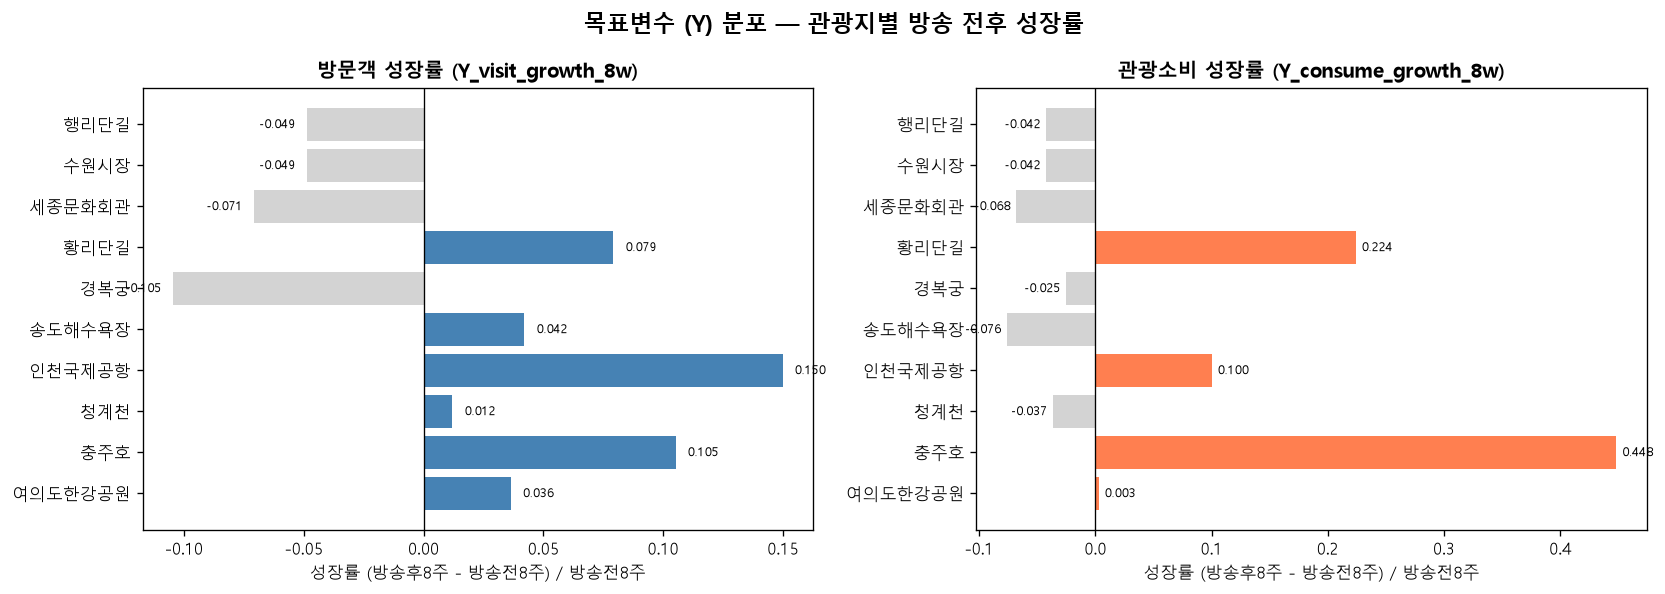


=== Y 변수 기술통계 ===
         Y_visit_growth_8w  Y_consume_growth_8w
관광지명_표준                                        
여의도한강공원             0.0364               0.0028
충주호                 0.1052               0.4482
청계천                 0.0121              -0.0367
인천국제공항              0.1499               0.1001
송도해수욕장              0.0421              -0.0762
경복궁                -0.1045              -0.0253
황리단길                0.0793               0.2240
세종문화회관             -0.0706              -0.0682
수원시장               -0.0486              -0.0422
행리단길               -0.0486              -0.0422


In [4]:
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
labels = df['관광지명_표준'].tolist()

for ax, col, title, color in zip(
    axes,
    y_cols,
    ['방문객 성장률 (Y_visit_growth_8w)', '관광소비 성장률 (Y_consume_growth_8w)'],
    ['steelblue', 'coral']
):
    vals = df[col].values
    colors = [color if v >= 0 else 'lightgray' for v in vals]
    bars = ax.barh(labels, vals, color=colors)
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontsize=12, fontweight='bold')
    ax.set_xlabel('성장률 (방송후8주 - 방송전8주) / 방송전8주')
    for bar, val in zip(bars, vals):
        ax.text(val + 0.005 if val >= 0 else val - 0.005,
                bar.get_y() + bar.get_height()/2,
                f'{val:.3f}', va='center',
                ha='left' if val >= 0 else 'right', fontsize=8)

plt.suptitle('목표변수 (Y) 분포 — 관광지별 방송 전후 성장률', fontsize=14, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_y_distribution.png', bbox_inches='tight')
plt.show()

print('\n=== Y 변수 기술통계 ===')
print(df[y_cols + ['관광지명_표준']].set_index('관광지명_표준').round(4).to_string())

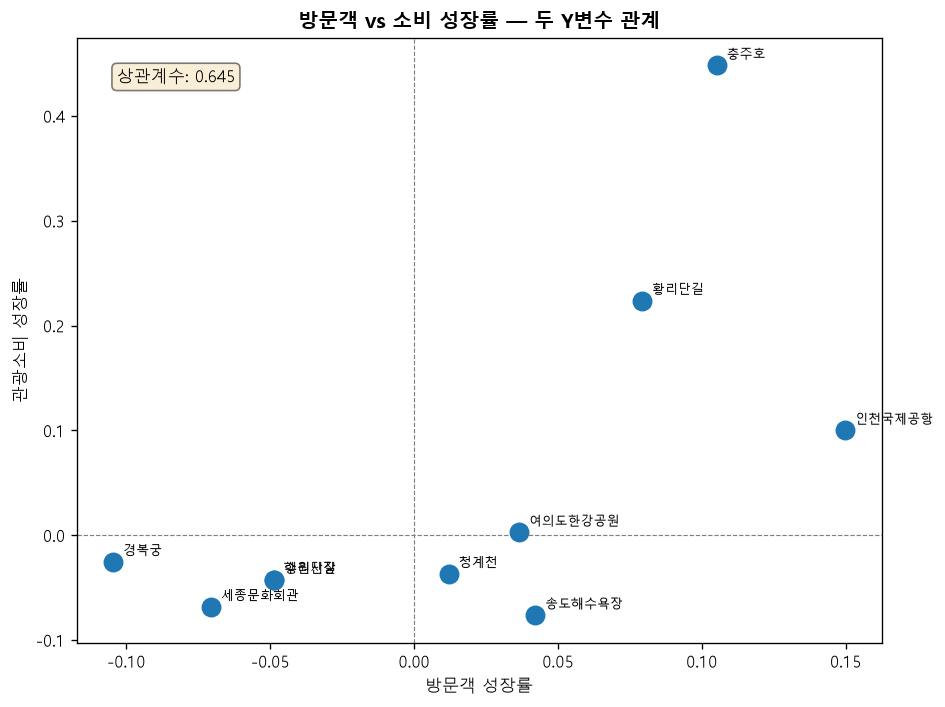

In [5]:
# 방문객 vs 소비 성장률 산점도 (n=10 전체 표시)
fig, ax = plt.subplots(figsize=(8, 6))
ax.scatter(df['Y_visit_growth_8w'], df['Y_consume_growth_8w'], s=120, zorder=5)
for _, row in df.iterrows():
    ax.annotate(row['관광지명_표준'],
                (row['Y_visit_growth_8w'], row['Y_consume_growth_8w']),
                textcoords='offset points', xytext=(6, 4), fontsize=8)
ax.axhline(0, color='gray', linewidth=0.7, linestyle='--')
ax.axvline(0, color='gray', linewidth=0.7, linestyle='--')
ax.set_xlabel('방문객 성장률')
ax.set_ylabel('관광소비 성장률')
ax.set_title('방문객 vs 소비 성장률 — 두 Y변수 관계', fontweight='bold')

corr = df['Y_visit_growth_8w'].corr(df['Y_consume_growth_8w'])
ax.text(0.05, 0.95, f'상관계수: {corr:.3f}', transform=ax.transAxes,
        fontsize=10, va='top', bbox=dict(boxstyle='round', facecolor='wheat', alpha=0.5))

plt.tight_layout()
plt.savefig('eda_y_scatter.png', bbox_inches='tight')
plt.show()

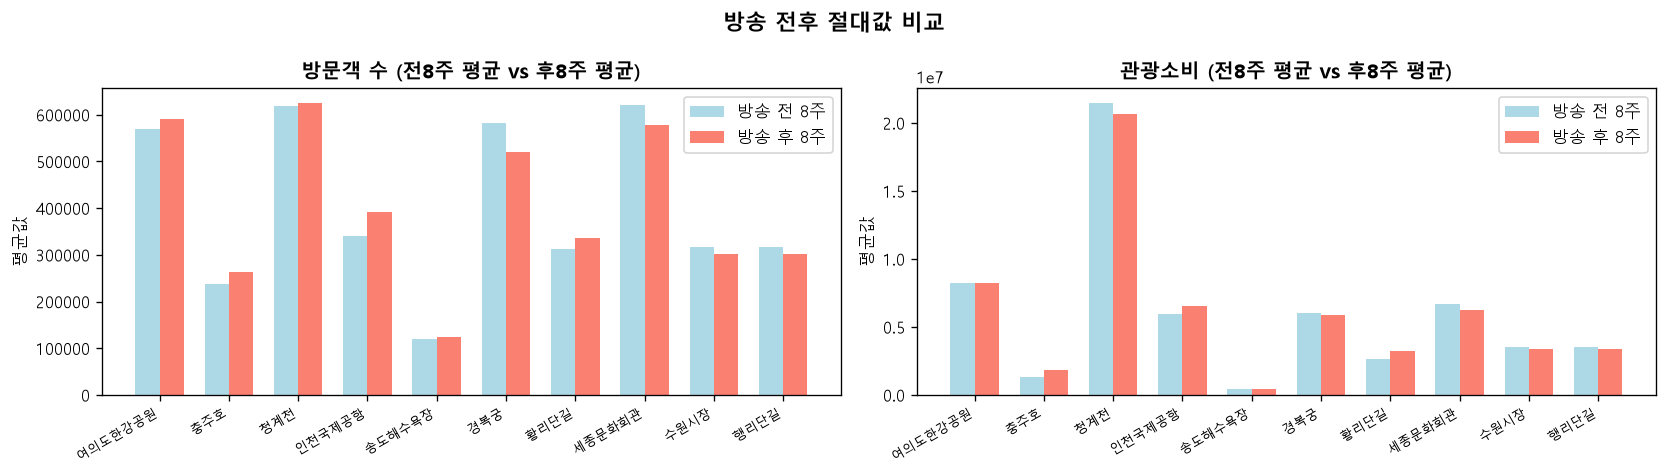


방문객 데이터 보유일수 (before/after):
         visit_before_days  visit_after_days  consume_before_days  consume_after_days
관광지명_표준                                                                              
여의도한강공원                 56                56                   56                  56
충주호                     56                56                   56                  56
청계천                     56                56                   56                  56
인천국제공항                  56                56                   56                  56
송도해수욕장                  56                56                   56                  56
경복궁                     56                56                   56                  56
황리단길                    56                56                   56                  56
세종문화회관                  56                56                   56                  56
수원시장                    56                56                   56                  56
행리단길                    

In [6]:
# 방문객 전/후 절대값 비교
fig, axes = plt.subplots(1, 2, figsize=(14, 4))
x = np.arange(len(df))
w = 0.35

for ax, before_col, after_col, title in zip(
    axes,
    ['visit_before8w_mean', 'consume_before8w_mean'],
    ['visit_after8w_mean', 'consume_after8w_mean'],
    ['방문객 수 (전8주 평균 vs 후8주 평균)', '관광소비 (전8주 평균 vs 후8주 평균)']
):
    ax.bar(x - w/2, df[before_col], w, label='방송 전 8주', color='lightblue')
    ax.bar(x + w/2, df[after_col], w, label='방송 후 8주', color='salmon')
    ax.set_xticks(x)
    ax.set_xticklabels(df['관광지명_표준'], rotation=30, ha='right', fontsize=8)
    ax.set_title(title, fontweight='bold')
    ax.legend()
    ax.set_ylabel('평균값')

plt.suptitle('방송 전후 절대값 비교', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_before_after.png', bbox_inches='tight')
plt.show()

print(f'\n방문객 데이터 보유일수 (before/after):')
print(df[['관광지명_표준', 'visit_before_days', 'visit_after_days', 'consume_before_days', 'consume_after_days']].set_index('관광지명_표준').to_string())

---
## 3. 결측값 분석

결측값 있는 특성: 18개
최근접공영주차장거리_m                2
네이버_연관검색지수_growth_8w        2
naver_검색지수_growth_8w        2
네이버_관광지지수_before8w_mean     1
네이버_드라마지수_before8w_mean     1
네이버_연관검색지수_before8w_mean    1
네이버_연관검색지수_during_mean      1
네이버_관광지지수_after8w_mean      1
네이버_관광지지수_during_mean       1
네이버_드라마지수_during_mean       1
네이버_연관검색지수_after8w_mean     1
네이버_드라마지수_after8w_mean      1
네이버_드라마지수_growth_8w         1
네이버_관광지지수_growth_8w         1
네이버_관광지지수_log_growth_8w     1
네이버_드라마지수_log_growth_8w     1
네이버_연관검색지수_log_growth_8w    1
naver_검색지수_log_growth_8w    1


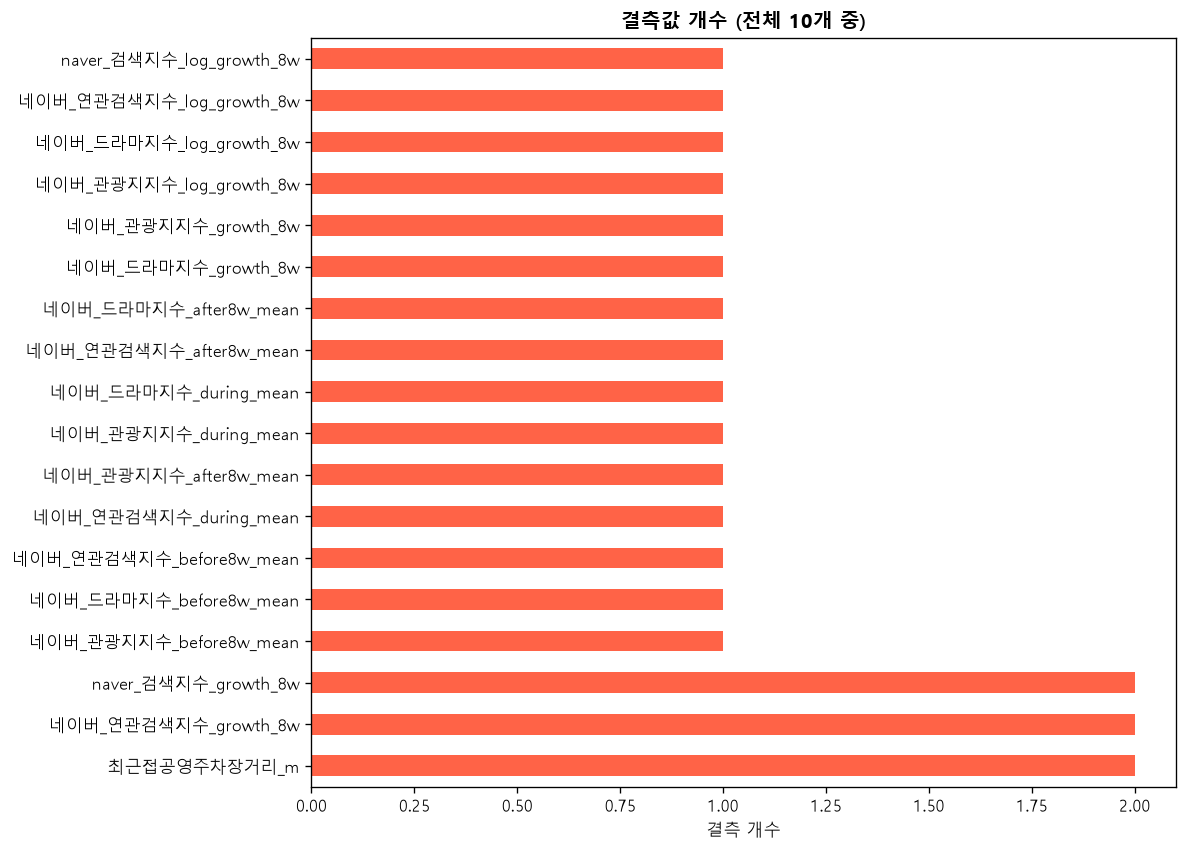

In [7]:
X_num = df[X_cols].select_dtypes(include=[np.number])

miss = X_num.isnull().sum()
miss = miss[miss > 0].sort_values(ascending=False)

if len(miss) == 0:
    print('수치형 X 특성에 결측값 없음')
else:
    print(f'결측값 있는 특성: {len(miss)}개')
    print(miss.to_string())
    
    fig, ax = plt.subplots(figsize=(10, max(3, len(miss)*0.4)))
    miss.plot(kind='barh', ax=ax, color='tomato')
    ax.set_title('결측값 개수 (전체 10개 중)', fontweight='bold')
    ax.set_xlabel('결측 개수')
    plt.tight_layout()
    plt.savefig('eda_missing.png', bbox_inches='tight')
    plt.show()

In [8]:
# 분산 0인 특성 (모든 값이 동일) 확인
zero_var = X_num.columns[X_num.std() == 0].tolist()
print(f'분산=0 (모든 값 동일, 제거 대상): {len(zero_var)}개')
for c in zero_var:
    print(f'  {c}: {X_num[c].unique()}')

분산=0 (모든 값 동일, 제거 대상): 3개
  택시_사용월수: [12]
  ic_available_days_before8w: [56]
  ic_available_days_after8w: [56]


---
## 4. X 특성 분포 확인

In [ ]:
# 수치형 특성 기술통계 (전체, CV 높은 순)
desc = X_num.describe().T
desc['cv'] = desc['std'] / (desc['mean'].abs() + 1e-9)  # 변동계수
pd.set_option('display.max_rows', None)
print(f'=== 수치형 특성 기술통계 (전체 {len(desc)}개, CV 높은 순) ===')
print(desc.sort_values('cv', ascending=False)[['mean','std','min','max','cv']].round(3).to_string())

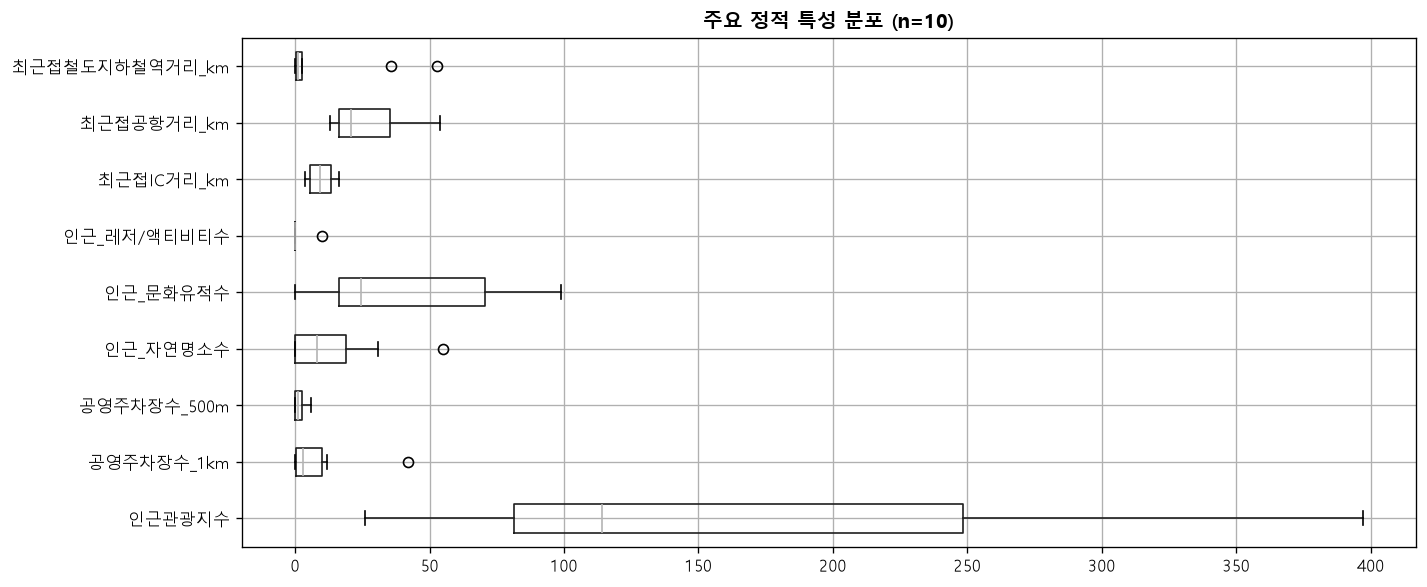

In [10]:
# 정적 특성 박스플롯 (주요 인프라)
static_plot_cols = [
    '인근관광지수', '공영주차장수_1km', '공영주차장수_500m',
    '인근_자연명소수', '인근_문화유적수', '인근_레저/액티비티수',
    '최근접IC거리_km', '최근접공항거리_km', '최근접철도지하철역거리_km',
]
static_plot_cols = [c for c in static_plot_cols if c in X_num.columns]

fig, ax = plt.subplots(figsize=(12, 5))
X_num[static_plot_cols].boxplot(ax=ax, vert=False)
ax.set_title('주요 정적 특성 분포 (n=10)', fontweight='bold')
plt.tight_layout()
plt.savefig('eda_static_dist.png', bbox_inches='tight')
plt.show()

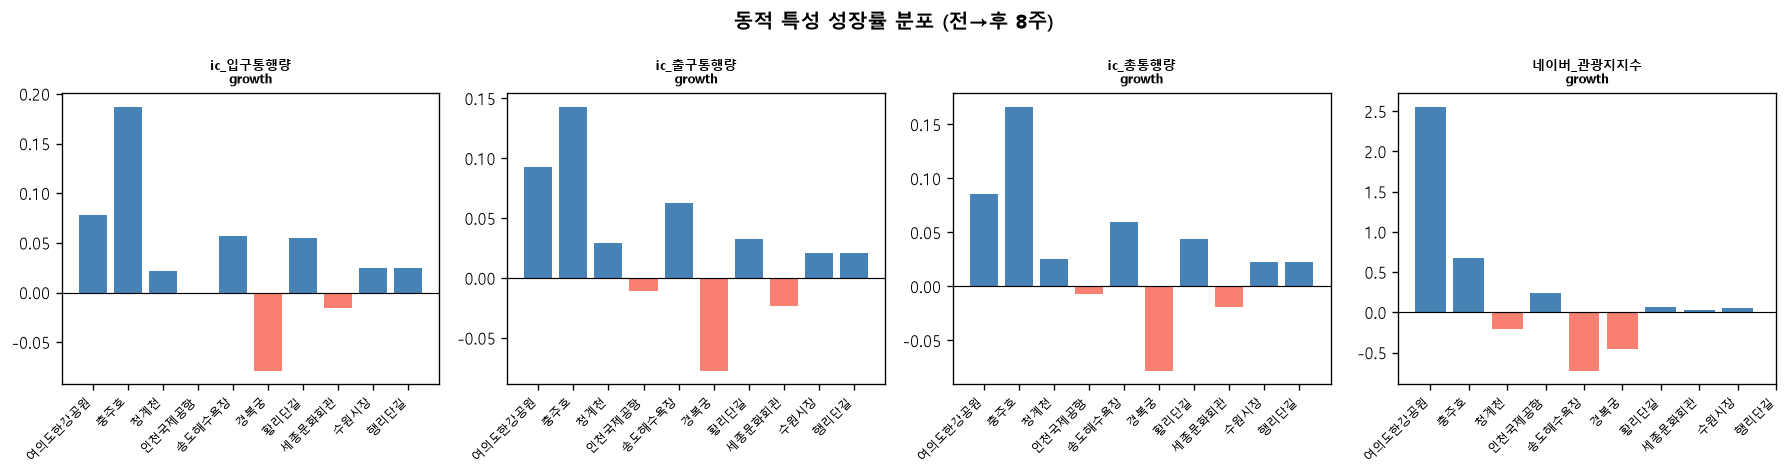

In [11]:
# 동적 성장률 특성 분포
growth_cols = [c for c in X_num.columns if 'growth_8w' in c and 'log' not in c]

fig, axes = plt.subplots(1, min(len(growth_cols), 4), figsize=(15, 4))
if len(growth_cols) == 1:
    axes = [axes]
for ax, col in zip(axes, growth_cols[:4]):
    vals = X_num[col].dropna()
    ax.bar(range(len(vals)), vals.values, color=['steelblue' if v >= 0 else 'salmon' for v in vals.values])
    ax.axhline(0, color='black', linewidth=0.7)
    ax.set_title(col.replace('_growth_8w','\ngrowth'), fontsize=8, fontweight='bold')
    ax.set_xticks(range(len(df)))
    ax.set_xticklabels(df['관광지명_표준'], rotation=45, ha='right', fontsize=7)

plt.suptitle('동적 특성 성장률 분포 (전→후 8주)', fontsize=12, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_dynamic_growth.png', bbox_inches='tight')
plt.show()

---
## 5. X-Y 상관관계 분석 (특성 선별 핵심)

In [ ]:
# 각 X 특성과 Y 변수의 상관계수 계산 (전체 특성 표시)
corr_visit = X_num.corrwith(df['Y_visit_growth_8w']).dropna().sort_values(key=abs, ascending=False)
corr_consume = X_num.corrwith(df['Y_consume_growth_8w']).dropna().sort_values(key=abs, ascending=False)

n_feat = max(len(corr_visit), len(corr_consume))
fig, axes = plt.subplots(1, 2, figsize=(16, max(6, n_feat * 0.3)))

for ax, corr, title, color in zip(
    axes,
    [corr_visit, corr_consume],
    [f'Y_visit_growth_8w 전체 {len(corr_visit)}개 상관 특성',
     f'Y_consume_growth_8w 전체 {len(corr_consume)}개 상관 특성'],
    ['steelblue', 'coral']
):
    colors = [color if v >= 0 else 'lightgray' for v in corr.values]
    ax.barh(corr.index[::-1], corr.values[::-1], color=colors[::-1])
    ax.axvline(0, color='black', linewidth=0.8)
    ax.set_title(title, fontweight='bold')
    ax.set_xlabel('Pearson 상관계수')
    ax.set_xlim(-1, 1)
    ax.tick_params(axis='y', labelsize=7)

plt.suptitle('X-Y 상관관계 (높을수록 유망 특성)', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_xy_corr.png', bbox_inches='tight')
plt.show()

pd.set_option('display.max_rows', None)
print(f'\n=== visit 상관 특성 (전체 {len(corr_visit)}개) ===')
print(corr_visit.round(3).to_string())
print(f'\n=== consume 상관 특성 (전체 {len(corr_consume)}개) ===')
print(corr_consume.round(3).to_string())

---
## 6. X-X 상관관계 — 중복 특성 파악

In [ ]:
# 전체 특성 간 상관 히트맵 (Y 상관 높은 순 정렬)
ordered = list(dict.fromkeys(corr_visit.abs().index.tolist() + corr_consume.abs().index.tolist()))
top_features = ordered  # 전체 특성

corr_matrix = X_num[top_features].corr()
n = len(corr_matrix)

# 특성이 많으면 annotation 가독성이 떨어지므로 자동 조정
annot = n <= 25

fig, ax = plt.subplots(figsize=(max(14, n * 0.45), max(12, n * 0.42)))
mask = np.triu(np.ones_like(corr_matrix, dtype=bool))
sns.heatmap(corr_matrix, mask=mask, cmap='RdBu_r', center=0,
            vmin=-1, vmax=1, annot=annot, fmt='.2f', annot_kws={'size': 6},
            ax=ax, linewidths=0.5, cbar_kws={'shrink': 0.5})
ax.set_title(f'전체 특성 간 상관관계 히트맵 ({n}개)\n(|r| > 0.8 이면 한쪽 제거 고려)', fontweight='bold')
ax.tick_params(labelsize=6)
plt.tight_layout()
plt.savefig('eda_feature_corr.png', bbox_inches='tight')
plt.show()

In [14]:
# 고상관 특성 쌍 목록 출력 (|r| >= 0.85)
threshold = 0.85
high_corr_pairs = []
for i in range(len(corr_matrix.columns)):
    for j in range(i+1, len(corr_matrix.columns)):
        r = corr_matrix.iloc[i, j]
        if abs(r) >= threshold:
            high_corr_pairs.append((corr_matrix.columns[i], corr_matrix.columns[j], round(r, 3)))

high_corr_pairs.sort(key=lambda x: abs(x[2]), reverse=True)
print(f'|r| >= {threshold} 인 특성 쌍 ({len(high_corr_pairs)}개) — 중복 제거 대상:')
for a, b, r in high_corr_pairs:
    print(f'  r={r:+.3f}  |  {a}  ↔  {b}')

|r| >= 0.85 인 특성 쌍 (75개) — 중복 제거 대상:
  r=+1.000  |  ic_총통행량_growth_8w  ↔  ic_통행량_growth_8w
  r=+1.000  |  택시_영업대수합계_연도월평균  ↔  택시_영업횟수합계_연도월평균
  r=+1.000  |  ic_입구통행량_before8w_mean  ↔  ic_총통행량_before8w_mean
  r=+1.000  |  ic_입구통행량_during_mean  ↔  ic_총통행량_during_mean
  r=+1.000  |  ic_총통행량_before8w_mean  ↔  ic_출구통행량_before8w_mean
  r=+1.000  |  ic_총통행량_during_mean  ↔  ic_출구통행량_during_mean
  r=+1.000  |  ic_입구통행량_after8w_mean  ↔  ic_총통행량_after8w_mean
  r=+1.000  |  ic_총통행량_after8w_mean  ↔  ic_출구통행량_after8w_mean
  r=+0.999  |  택시_운행거리합계_km_연도월평균  ↔  택시_영업대수합계_연도월평균
  r=+0.998  |  택시_운행거리합계_km_연도월평균  ↔  택시_영업횟수합계_연도월평균
  r=+0.998  |  ic_입구통행량_before8w_mean  ↔  ic_입구통행량_during_mean
  r=+0.998  |  ic_입구통행량_before8w_mean  ↔  ic_총통행량_during_mean
  r=+0.998  |  ic_입구통행량_before8w_mean  ↔  ic_출구통행량_before8w_mean
  r=+0.998  |  ic_입구통행량_during_mean  ↔  ic_입구통행량_after8w_mean
  r=+0.998  |  ic_입구통행량_during_mean  ↔  ic_총통행량_after8w_mean
  r=+0.998  |  ic_입구통행량_during_mean  ↔  ic_출구통행량_during_mean
  r=

---
## 7. 산점도 — 주요 특성 vs Y

In [ ]:
# 전체 특성 vs 방문객 성장률 산점도 (상관 높은 순)
feats_visit = corr_visit.abs().index.tolist()

ncols = 3
nrows = int(np.ceil(len(feats_visit) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for ax, feat in zip(axes, feats_visit):
    x_vals = X_num[feat]
    y_vals = df['Y_visit_growth_8w']
    valid = x_vals.notna() & y_vals.notna()
    ax.scatter(x_vals[valid], y_vals[valid], s=80, zorder=5)
    for idx in df[valid].index:
        ax.annotate(df.loc[idx, '관광지명_표준'],
                    (x_vals[idx], y_vals[idx]),
                    textcoords='offset points', xytext=(4, 3), fontsize=7)
    r = x_vals[valid].corr(y_vals[valid])
    ax.set_title(f'{feat}\nr={r:.3f}', fontsize=8, fontweight='bold')
    ax.set_ylabel('Y_visit_growth_8w', fontsize=7)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# 남는 빈 subplot 숨김
for ax in axes[len(feats_visit):]:
    ax.axis('off')

plt.suptitle('전체 X 특성 vs 방문객 성장률 산점도', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_scatter_visit.png', bbox_inches='tight')
plt.show()

In [ ]:
# 전체 특성 vs 관광소비 성장률 산점도 (상관 높은 순)
feats_consume = corr_consume.abs().index.tolist()

ncols = 3
nrows = int(np.ceil(len(feats_consume) / ncols))
fig, axes = plt.subplots(nrows, ncols, figsize=(15, 4 * nrows))
axes = axes.flatten()

for ax, feat in zip(axes, feats_consume):
    x_vals = X_num[feat]
    y_vals = df['Y_consume_growth_8w']
    valid = x_vals.notna() & y_vals.notna()
    ax.scatter(x_vals[valid], y_vals[valid], s=80, zorder=5, color='coral')
    for idx in df[valid].index:
        ax.annotate(df.loc[idx, '관광지명_표준'],
                    (x_vals[idx], y_vals[idx]),
                    textcoords='offset points', xytext=(4, 3), fontsize=7)
    r = x_vals[valid].corr(y_vals[valid])
    ax.set_title(f'{feat}\nr={r:.3f}', fontsize=8, fontweight='bold')
    ax.set_ylabel('Y_consume_growth_8w', fontsize=7)
    ax.axhline(0, color='gray', linewidth=0.5, linestyle='--')

# 남는 빈 subplot 숨김
for ax in axes[len(feats_consume):]:
    ax.axis('off')

plt.suptitle('전체 X 특성 vs 관광소비 성장률 산점도', fontsize=13, fontweight='bold')
plt.tight_layout()
plt.savefig('eda_scatter_consume.png', bbox_inches='tight')
plt.show()

---
## 8. EDA 종합 — 모델링용 특성 후보 선별

In [17]:
# 두 Y 모두 |r| >= 0.3 이상인 특성만 추림
min_corr = 0.30

candidate_visit = set(corr_visit[corr_visit.abs() >= min_corr].index)
candidate_consume = set(corr_consume[corr_consume.abs() >= min_corr].index)
candidates_union = candidate_visit | candidate_consume

summary = pd.DataFrame({
    'r_visit': corr_visit,
    'r_consume': corr_consume,
}).loc[list(candidates_union)]
summary['|r|_max'] = summary.abs().max(axis=1)
summary = summary.sort_values('|r|_max', ascending=False)

print(f'=== 후보 특성 (visit 또는 consume |r| >= {min_corr}) — {len(summary)}개 ===')
print(summary.round(3).to_string())

=== 후보 특성 (visit 또는 consume |r| >= 0.3) — 38개 ===
                          r_visit  r_consume  |r|_max
최근접철도지하철역거리_km              0.508      0.948    0.948
ic_입구통행량_growth_8w          0.601      0.719    0.719
최근접공항거리_km                  0.336      0.695    0.695
ic_총통행량_growth_8w           0.585      0.653    0.653
ic_통행량_growth_8w            0.585      0.653    0.653
ic_입구통행량_during_mean       -0.412     -0.611    0.611
ic_입구통행량_after8w_mean      -0.385     -0.610    0.610
ic_입구통행량_before8w_mean     -0.425     -0.606    0.606
ic_총통행량_during_mean        -0.389     -0.597    0.597
ic_총통행량_after8w_mean       -0.363     -0.596    0.596
ic_총통행량_before8w_mean      -0.402     -0.592    0.592
인근_자연명소수                    0.458      0.588    0.588
ic_출구통행량_during_mean       -0.366     -0.583    0.583
ic_출구통행량_after8w_mean      -0.341     -0.582    0.582
ic_출구통행량_before8w_mean     -0.380     -0.578    0.578
인근_문화/액티비티수                 0.573      0.108    0.573
네이버_관광지지수_log_growth_8w     0.56

In [18]:
# 고상관 중복 제거 후 최종 추천 특성 (수동 검토)
# ic 입출구 통행량은 총통행량과 중복 → 총통행량만 유지
# 500m/1km/2km 주차장 수 → 1km만 유지
# before/during/after 평균 중 growth_8w가 직접 차이를 담으므로 growth 우선

print('\n=== EDA 요약 ===')
print(f'  총 X 수치 특성:  {len(X_num.columns)}개')
print(f'  분산=0 제거:     {len(zero_var)}개')
print(f'  Y 상관 후보:     {len(candidates_union)}개 (|r| >= {min_corr})')
print(f'  고상관 쌍(중복): {len(high_corr_pairs)}쌍 (|r| >= {threshold})')
print()
print('모델링 권장사항:')
print('  1. 위 후보 특성에서 중복 제거 후 8~12개로 최종 선정')
print('  2. 검증 전략: Leave-One-Out CV (n=10)')
print('  3. 모델: XGBoost (max_depth=2~3) + SHAP')
print('  4. Y_visit / Y_consume 각각 별도 모델 학습')


=== EDA 요약 ===
  총 X 수치 특성:  65개
  분산=0 제거:     3개
  Y 상관 후보:     38개 (|r| >= 0.3)
  고상관 쌍(중복): 75쌍 (|r| >= 0.85)

모델링 권장사항:
  1. 위 후보 특성에서 중복 제거 후 8~12개로 최종 선정
  2. 검증 전략: Leave-One-Out CV (n=10)
  3. 모델: XGBoost (max_depth=2~3) + SHAP
  4. Y_visit / Y_consume 각각 별도 모델 학습
